## Time history diagnostics

In [1]:
# Import needed modules
import numpy as np
import matplotlib.pylab as plt
import os

In [2]:
# Set working directory
sim_name = "Weibel"
tail = ""
pathname = '/raven/ptmp/sonnen/gempic_gpu_runs/'+sim_name + tail
pathname_out = pathname + '/processed'
try:
    os.mkdir(pathname_out)
except(FileExistsError):
    
    pass
os.chdir(pathname)

In [3]:
# Read time history output file
file = open(sim_name + '.txt', 'r')
lines = file.readlines()
nsteps = len(lines)-1  # First line is not counted
print("nsteps=",nsteps)
time = np.zeros(nsteps)
ex = np.zeros(nsteps)
ey = np.zeros(nsteps)
ez = np.zeros(nsteps)
bx = np.zeros(nsteps)
by = np.zeros(nsteps)
bz = np.zeros(nsteps)
ekin = np.zeros(nsteps)
px = np.zeros(nsteps)
py = np.zeros(nsteps)
pz = np.zeros(nsteps)
errgauss = np.zeros(nsteps)
totenergy = np.zeros(nsteps)
errenergy = np.zeros(nsteps)

for i in range(nsteps):
    vals = lines[i+1].rstrip().split(' ')
    time[i] = vals[0]
    ex[i] = vals[1]
    ey[i] = vals[2]
    ez[i] = vals[3]
    bx[i] = vals[4]
    by[i] = vals[5]
    bz[i] = vals[6]
    ekin[i] = vals[7]
    px[i] = vals[8]
    py[i] = vals[9]
    pz[i] = vals[10]
    errgauss[i] = vals[11]
    totenergy[i] = vals[12]
    errenergy[i] = vals[13]

# Close opened file
file.close()

nsteps= 20001


Text(0.5, 1.0, 'Gauss error')

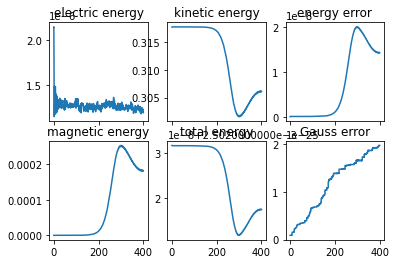

In [6]:
fig, axs = plt.subplots(2, 3,sharex=True,tight_layout=False)
axs[0,0].plot(time,ex+ey+ez)
axs[0,0].set_title('electric energy')
axs[1,0].plot(time,bx+by+bz)
axs[1,0].set_title('magnetic energy')
axs[0,1].plot(time,ekin)
axs[0,1].set_title('kinetic energy')
axs[1,1].plot(time,totenergy)
axs[1,1].set_title('total energy')
axs[0,2].plot(time,errenergy)
axs[0,2].set_title('energy error')
axs[1,2].plot(time,errgauss)
axs[1,2].set_title('Gauss error')

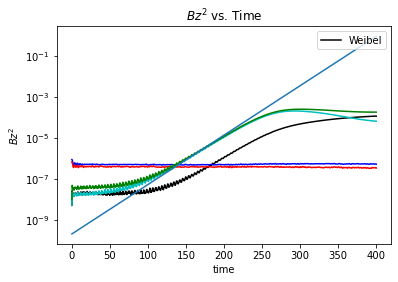

In [10]:
# Plot |Bz|**2 
fig, ax = plt.subplots()
ax.semilogy(time, bz, 'k')
ax.semilogy(time, ex, 'b')
ax.semilogy(time, ey, 'r')
ax.semilogy(time, by, 'c')
ax.semilogy(time, by, 'g')
ax.semilogy(time,2e-10*np.exp(2*0.02784*time))
ax.set_xlabel('time')
ax.set_ylabel('$Bz^2$')
ax.set_title('$\frac 12 Bz^2$ vs. Time')
ax.legend([sim_name],loc='upper right')
plt.savefig(pathname_out + '/B3_squared_vs_t.jpg');

growth rate 0.013630705540547744
frequency 2.5672584992685805
[-0.10984699 -0.0052556   0.0035765   0.12056792 -0.07905205  0.10304658
  0.01707423 -0.10760602  0.10971453  0.01236528 -0.0065312   0.0244228
 -0.07067407 -0.01349485  0.11594128  0.01702133  0.01774753 -0.05833751
  0.08253523  0.02207061  0.02160783  0.02404789  0.02224801  0.02232782
  0.02472751  0.02333955  0.02352982  0.02454579]
[ 3.97669956 19.63495408 24.16609734  3.30693964  3.11048778  3.27249235
  1.62776821  3.87850945  2.8821951   1.52504498 28.55993321  1.7749111
  3.61102604 14.95996502  3.34211984  1.57868978  1.55524389  3.83121055
  2.85599332  1.57868978  1.63624617  1.58666296  1.57868978  1.55524389
  1.61937766  1.55524389  1.58666296  1.61937766]
5e-09 5e-09


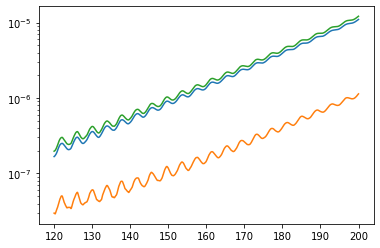

In [11]:
from scipy.signal import find_peaks

i1 = 6000
i2 = 10000
plt.semilogy(time[i1:i2],by[i1:i2])
plt.semilogy(time[i1:i2],bz[i1:i2])
plt.semilogy(time[i1:i2],by[i1:i2]+bz[i1:i2])

imax, Eval_dict = find_peaks(bz[i1:i2],height=0)
Eval = Eval_dict['peak_heights']
slope = np.zeros(Eval.shape)
freq = np.zeros(Eval.shape)
for i in range(Eval.size-1):
    slope[i] = (np.log(Eval[i+1])-np.log(Eval[i]))/(time[imax[i+1]]-time[imax[i]])
    freq[i] = np.pi / (time[imax[i+1]] - time[imax[i]])
slope_av = np.average(slope[:-1])
freq_av = np.average(freq[:-1])
print("growth rate", slope_av/2)
print("frequency", freq_av)
print(slope[:-1]/2)
print(2*freq[:-1])
#print(imax)
print(by[0],bz[0])

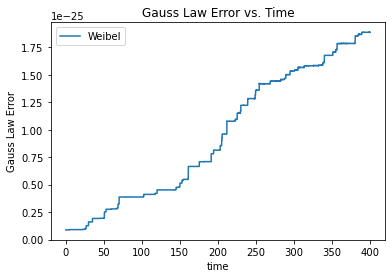

In [35]:
# Plot Gauss Law Error 
fig, ax = plt.subplots()
ax.plot(time, errgauss);
ax.set_xlabel('time');
ax.set_ylabel('Gauss Law Error');
ax.set_title('Gauss Law Error vs. Time');
ax.legend([sim_name],loc='upper left')
plt.savefig(pathname_out + '/Gauss_Law_Error_vs_t.jpg');

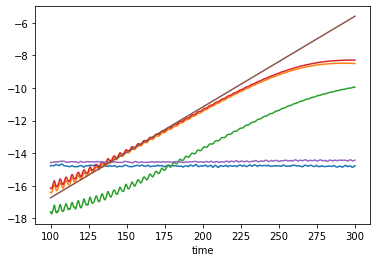

In [17]:
# Plot |E2|**2, |B3|**2 actual and theoretical growth rate
fig, ax = plt.subplots()
i1 = 5000
i2 = 15000
ax.plot(time[i1:i2], np.log(ey[i1:i2]))
ax.plot(time[i1:i2], np.log(by[i1:i2]))
ax.plot(time[i1:i2], np.log(bz[i1:i2]))
ax.plot(time[i1:i2], np.log(by[i1:i2]+bz[i1:i2]))
ax.plot(time[i1:i2], np.log(ex[i1:i2]))
ax.plot(time[i1:i2], 2*0.02784*time[i1:i2] - 22.3)
ax.set_xlabel('time');